In [1]:
import numpy as np
import pandas as pd
from IPython.display import display

# Flushing-round recalculation for the v3 analysis note.
# MPT.csv stores the midpoint time of each collection interval (days). Reconstruct
# the interval end time recursively, then integrate Q over each interval.
Vw_mL = 38.33
mpt_days = np.loadtxt('./data/MPT.csv', delimiter=',')

interval_end_days = np.empty_like(mpt_days, dtype=float)
previous_end = 0.0
for i, midpoint in enumerate(mpt_days):
    interval_end_days[i] = 2 * midpoint - previous_end
    previous_end = interval_end_days[i]

interval_days = np.diff(interval_end_days, prepend=0.0)
interval_minutes = interval_days * 24 * 60

case_order = [
    ('4C', 'S'), ('4C', 'M'), ('4C', 'L'),
    ('20C', 'S'), ('20C', 'M'), ('20C', 'L'),
    ('40C', 'S'), ('40C', 'M'), ('40C', 'L'),
]

temp_labels = {'4C': '4 degC', '20C': '20 degC', '40C': '40 degC'}
size_labels = {'S': '90-212 um', 'M': '212-500 um', 'L': '500-1000 um'}

round_rows = []
volume_rows = []
for temp, size in case_order:
    q_path = f'./data/Q_{temp}_{size}.csv'
    q_mL_min = np.genfromtxt(q_path, delimiter=',')
    if q_mL_min.ndim == 1:
        q_mL_min = q_mL_min[:, np.newaxis]

    volume_mL_by_rep = np.cumsum(q_mL_min * interval_minutes[:, np.newaxis], axis=0)
    flushing_rounds_by_rep = volume_mL_by_rep / Vw_mL

    mean_rounds = np.nanmean(flushing_rounds_by_rep, axis=1)
    mean_volume = np.nanmean(volume_mL_by_rep, axis=1)

    round_rows.append({
        'Temp': temp_labels[temp],
        'Size': size_labels[size],
        **{f'Pt{i + 1}': value for i, value in enumerate(mean_rounds)},
    })
    volume_rows.append({
        'Temp': temp_labels[temp],
        'Size': size_labels[size],
        **{f'Pt{i + 1}': value for i, value in enumerate(mean_volume)},
    })

flushing_round_table_v3 = pd.DataFrame(round_rows)
cumulative_volume_table_v3 = pd.DataFrame(volume_rows)
interval_table_v3 = pd.DataFrame({
    'Pt': [f'Pt{i + 1}' for i in range(len(mpt_days))],
    'MPT_days': mpt_days,
    'interval_end_days': interval_end_days,
    'interval_days': interval_days,
    'interval_minutes': interval_minutes,
})

print(f'Effective pore-water volume Vw = {Vw_mL:.2f} mL')
print('Integration uses Q_i * interval_minutes_i, where interval endpoints are reconstructed from MPT midpoints.')
print('Sampling interval check:')
display(interval_table_v3.round({'MPT_days': 3, 'interval_end_days': 3, 'interval_days': 3, 'interval_minutes': 1}))

print('Mean cumulative pumped volume (mL):')
display(cumulative_volume_table_v3.round(1))

print('Mean flushing rounds = cumulative pumped volume / Vw:')
display(flushing_round_table_v3.round(2))


Effective pore-water volume Vw = 38.33 mL
Integration uses Q_i * interval_minutes_i, where interval endpoints are reconstructed from MPT midpoints.
Sampling interval check:


,Pt,MPT_days,interval_end_days,interval_days,interval_minutes
0,Pt1,0.065,0.13,0.13,187.2
1,Pt2,0.190,0.25,0.12,172.8
2,Pt3,0.375,0.50,0.25,360.0
3,Pt4,0.750,1.00,0.50,720.0
4,Pt5,1.500,2.00,1.00,1440.0
5,Pt6,3.000,4.00,2.00,2880.0
6,Pt7,6.000,8.00,4.00,5760.0
7,Pt8,11.500,15.00,7.00,10080.0
8,Pt9,23.500,32.00,17.00,24480.0


Mean cumulative pumped volume (mL):


,Temp,Size,Pt1,Pt2,Pt3,Pt4,Pt5,Pt6,Pt7,Pt8,Pt9
0,4 degC,90-212 um,78.6,99.4,149.8,250.6,466.6,898.6,1762.6,2468.2,5895.4
1,4 degC,212-500 um,39.3,61.8,115.8,223.8,425.4,828.6,1635.0,3046.2,6228.6
2,4 degC,500-1000 um,88.0,112.2,169.8,285.0,501.0,933.0,1797.0,2603.4,5296.2
3,20 degC,90-212 um,26.2,33.1,61.9,177.1,450.7,1141.9,1545.1,3157.9,6340.3
4,20 degC,212-500 um,18.7,25.6,54.4,169.6,486.4,1177.6,1580.8,3193.6,6620.8
5,20 degC,500-1000 um,30.0,36.9,65.7,180.9,497.7,1131.3,1534.5,3147.3,6574.5
6,40 degC,90-212 um,30.0,57.6,111.6,219.6,435.6,781.2,1242.0,2350.8,5043.6
7,40 degC,212-500 um,28.1,52.3,102.7,153.1,181.9,527.5,1161.1,2169.1,4617.1
8,40 degC,500-1000 um,30.0,57.6,111.6,219.6,435.6,781.2,1242.0,2350.8,5043.6


Mean flushing rounds = cumulative pumped volume / Vw:


,Temp,Size,Pt1,Pt2,Pt3,Pt4,Pt5,Pt6,Pt7,Pt8,Pt9
0,4 degC,90-212 um,2.05,2.59,3.91,6.54,12.17,23.44,45.98,64.39,153.81
1,4 degC,212-500 um,1.03,1.61,3.02,5.84,11.10,21.62,42.66,79.47,162.50
2,4 degC,500-1000 um,2.30,2.93,4.43,7.43,13.07,24.34,46.88,67.92,138.17
3,20 degC,90-212 um,0.68,0.86,1.62,4.62,11.76,29.79,40.31,82.39,165.41
4,20 degC,212-500 um,0.49,0.67,1.42,4.43,12.69,30.72,41.24,83.32,172.73
5,20 degC,500-1000 um,0.78,0.96,1.71,4.72,12.98,29.51,40.03,82.11,171.52
6,40 degC,90-212 um,0.78,1.50,2.91,5.73,11.36,20.38,32.40,61.33,131.58
7,40 degC,212-500 um,0.73,1.36,2.68,3.99,4.74,13.76,30.29,56.59,120.46
8,40 degC,500-1000 um,0.78,1.50,2.91,5.73,11.36,20.38,32.40,61.33,131.58


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Read the time variable (EPT) in days
time = np.loadtxt('./data/EPT.csv', delimiter=',')

# Temperature and size configurations
temperatures = ['4C', '20C', '40C']
sizes = ['S', 'M', 'L']
size_labels = {'S': '90-212 um', 'M': '212-500 um', 'L': '500-1000 um'}
flushing_size_labels = {'S': '90-212 um', 'M': '212-500 um', 'L': '500-1000 um'}
temp_labels = {'4C': '4 degC', '20C': '20 degC', '40C': '40 degC'}
flushing_threshold = 1.0
pt_cols = [f'Pt{i + 1}' for i in range(len(time))]

print('Data loaded successfully!')
print(f'Time points: {time}')
print(f'Number of conditions to analyze: {len(temperatures) * len(sizes)}')
print(f'Effective data criterion: flushing rounds N > {flushing_threshold:.1f}')


Data loaded successfully!
Time points: [ 0.13  0.25  0.5   1.    2.    4.    8.   15.   32.  ]
Number of conditions to analyze: 9
Effective data criterion: flushing rounds N > 1.0


In [3]:
# Define the first-order leaching model
def first_order_model(t, M_inf, tau):
    """
    First-order leaching model: M(t) = M_inf * (1 - exp(-t/tau))
    """
    return M_inf * (1 - np.exp(-t / tau))


def get_effective_indices(temp, size, threshold=1.0):
    """
    Determine which data points are effective using the v3 flushing-round table.
    Points with flushing rounds > threshold are considered effective.
    """
    row = flushing_round_table_v3.loc[
        (flushing_round_table_v3['Temp'] == temp_labels[temp]) &
        (flushing_round_table_v3['Size'] == flushing_size_labels[size]),
        pt_cols,
    ]
    if row.empty:
        raise ValueError(f'No flushing-round row found for {temp}_{size}. Run the first cell first.')
    rounds = row.iloc[0].to_numpy(dtype=float)
    return np.where(rounds > threshold)[0], rounds


def format_sigfig(value, sig=3, use_comma=False):
    """Format a numeric value with a fixed number of significant figures."""
    if not np.isfinite(value):
        return 'nan'
    if value == 0:
        return '0'
    magnitude = int(np.floor(np.log10(abs(value))))
    digits = sig - magnitude - 1
    rounded = round(value, digits)
    if rounded != 0:
        magnitude = int(np.floor(np.log10(abs(rounded))))
        digits = sig - magnitude - 1
        rounded = round(value, digits)
    decimals = max(digits, 0)
    comma = ',' if use_comma else ''
    return f'{rounded:{comma}.{decimals}f}'


def format_value_with_error(value, error, sig=3, use_comma=False):
    """Format value +/- error with matching significant figures."""
    return f'{format_sigfig(value, sig=sig, use_comma=use_comma)} +/- {format_sigfig(error, sig=sig, use_comma=use_comma)}'


print('Functions defined successfully!')
print('First-order model: M(t) = M_inf * (1 - exp(-t/tau))')


Functions defined successfully!
First-order model: M(t) = M_inf * (1 - exp(-t/tau))


In [4]:
# Perform regression for all conditions (without bootstrapping)
results = {}

for temp in temperatures:
    for size in sizes:
        condition = (temp, size)
        print('')
        print(f'Processing: {temp}, {size_labels[size]}')
        
        # Load data
        filename = f'./data/PPDQ_{temp}_{size}.csv'
        ppdq_data = np.loadtxt(filename, delimiter=',')
        
        # Calculate mean and std across replicates
        ppdq_mean = np.nanmean(ppdq_data, axis=1)
        ppdq_std = np.nanstd(ppdq_data, axis=1)
        ppdq_sem = ppdq_std / np.sqrt(np.sum(~np.isnan(ppdq_data), axis=1))
        
        # Get effective data indices from v3 flushing rounds (Vw = 38.33 mL)
        effective_idx, flush_rounds = get_effective_indices(temp, size, threshold=flushing_threshold)
        
        # Use only effective data points for fitting
        time_eff = time[effective_idx]
        ppdq_mean_eff = ppdq_mean[effective_idx]
        ppdq_std_eff = ppdq_std[effective_idx]
        ppdq_sem_eff = ppdq_sem[effective_idx]
        
        first_pt = effective_idx[0] + 1 if len(effective_idx) else None
        print(f'  Total points: {len(time)}, Effective points: {len(time_eff)}, first retained point: Pt{first_pt}')
        print(f'  Effective indices: {effective_idx}')
        print(f'  Flushing rounds used: {np.round(flush_rounds[effective_idx], 2)}')
        
        # Fit the model using effective data
        try:
            # Initial guess: M_inf = max value * 1.5, tau = median time
            p0 = [np.max(ppdq_mean_eff) * 1.5, np.median(time_eff)]
            
            # Perform curve fitting with bounds
            popt, pcov = curve_fit(first_order_model, time_eff, ppdq_mean_eff, 
                                   p0=p0, 
                                   bounds=([0, 0], [np.inf, np.inf]),
                                   maxfev=10000)
            
            M_inf_fit, tau_fit = popt
            
            # Calculate standard errors from covariance matrix
            perr = np.sqrt(np.diag(pcov))
            M_inf_err, tau_err = perr
            
            # Store results
            results[condition] = {
                'time': time,
                'time_eff': time_eff,
                'effective_idx': effective_idx,
                'flush_rounds': flush_rounds,
                'ppdq_mean': ppdq_mean,
                'ppdq_std': ppdq_std,
                'ppdq_sem': ppdq_sem,
                'ppdq_mean_eff': ppdq_mean_eff,
                'ppdq_std_eff': ppdq_std_eff,
                'ppdq_sem_eff': ppdq_sem_eff,
                'ppdq_data': ppdq_data,
                'M_inf': M_inf_fit,
                'tau': tau_fit,
                'M_inf_err': M_inf_err,
                'tau_err': tau_err,
                'pcov': pcov,
            }
            
            print(f'  M_inf = {format_value_with_error(M_inf_fit, M_inf_err, use_comma=True)} ng')
            print(f'  tau = {format_value_with_error(tau_fit, tau_err)} days')
            
        except Exception as e:
            print(f'  Error fitting {condition}: {e}')
            results[condition] = None

print('')
print('=' * 80)
print('All regressions completed!')



Processing: 4C, 90-212 um
  Total points: 9, Effective points: 9, first retained point: Pt1
  Effective indices: [0 1 2 3 4 5 6 7 8]
  Flushing rounds used: [  2.05   2.59   3.91   6.54  12.17  23.44  45.98  64.39 153.81]
  M_inf = 14,800 +/- 2,940 ng
  tau = 45.9 +/- 12.1 days

Processing: 4C, 212-500 um
  Total points: 9, Effective points: 9, first retained point: Pt1
  Effective indices: [0 1 2 3 4 5 6 7 8]
  Flushing rounds used: [  1.03   1.61   3.02   5.84  11.1   21.62  42.66  79.47 162.5 ]
  M_inf = 28,400 +/- 6,090 ng
  tau = 71.5 +/- 18.5 days

Processing: 4C, 500-1000 um
  Total points: 9, Effective points: 9, first retained point: Pt1
  Effective indices: [0 1 2 3 4 5 6 7 8]
  Flushing rounds used: [  2.3    2.93   4.43   7.43  13.07  24.34  46.88  67.92 138.17]
  M_inf = 14,200 +/- 2,540 ng
  tau = 45.9 +/- 10.9 days

Processing: 20C, 90-212 um
  Total points: 9, Effective points: 7, first retained point: Pt3
  Effective indices: [2 3 4 5 6 7 8]
  Flushing rounds used: [ 

C:\Users\huan111\AppData\Local\Temp\ipykernel_35436\3401279720.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0.03, 1, 0.96])  # Adjust layout to make room for labels and legend


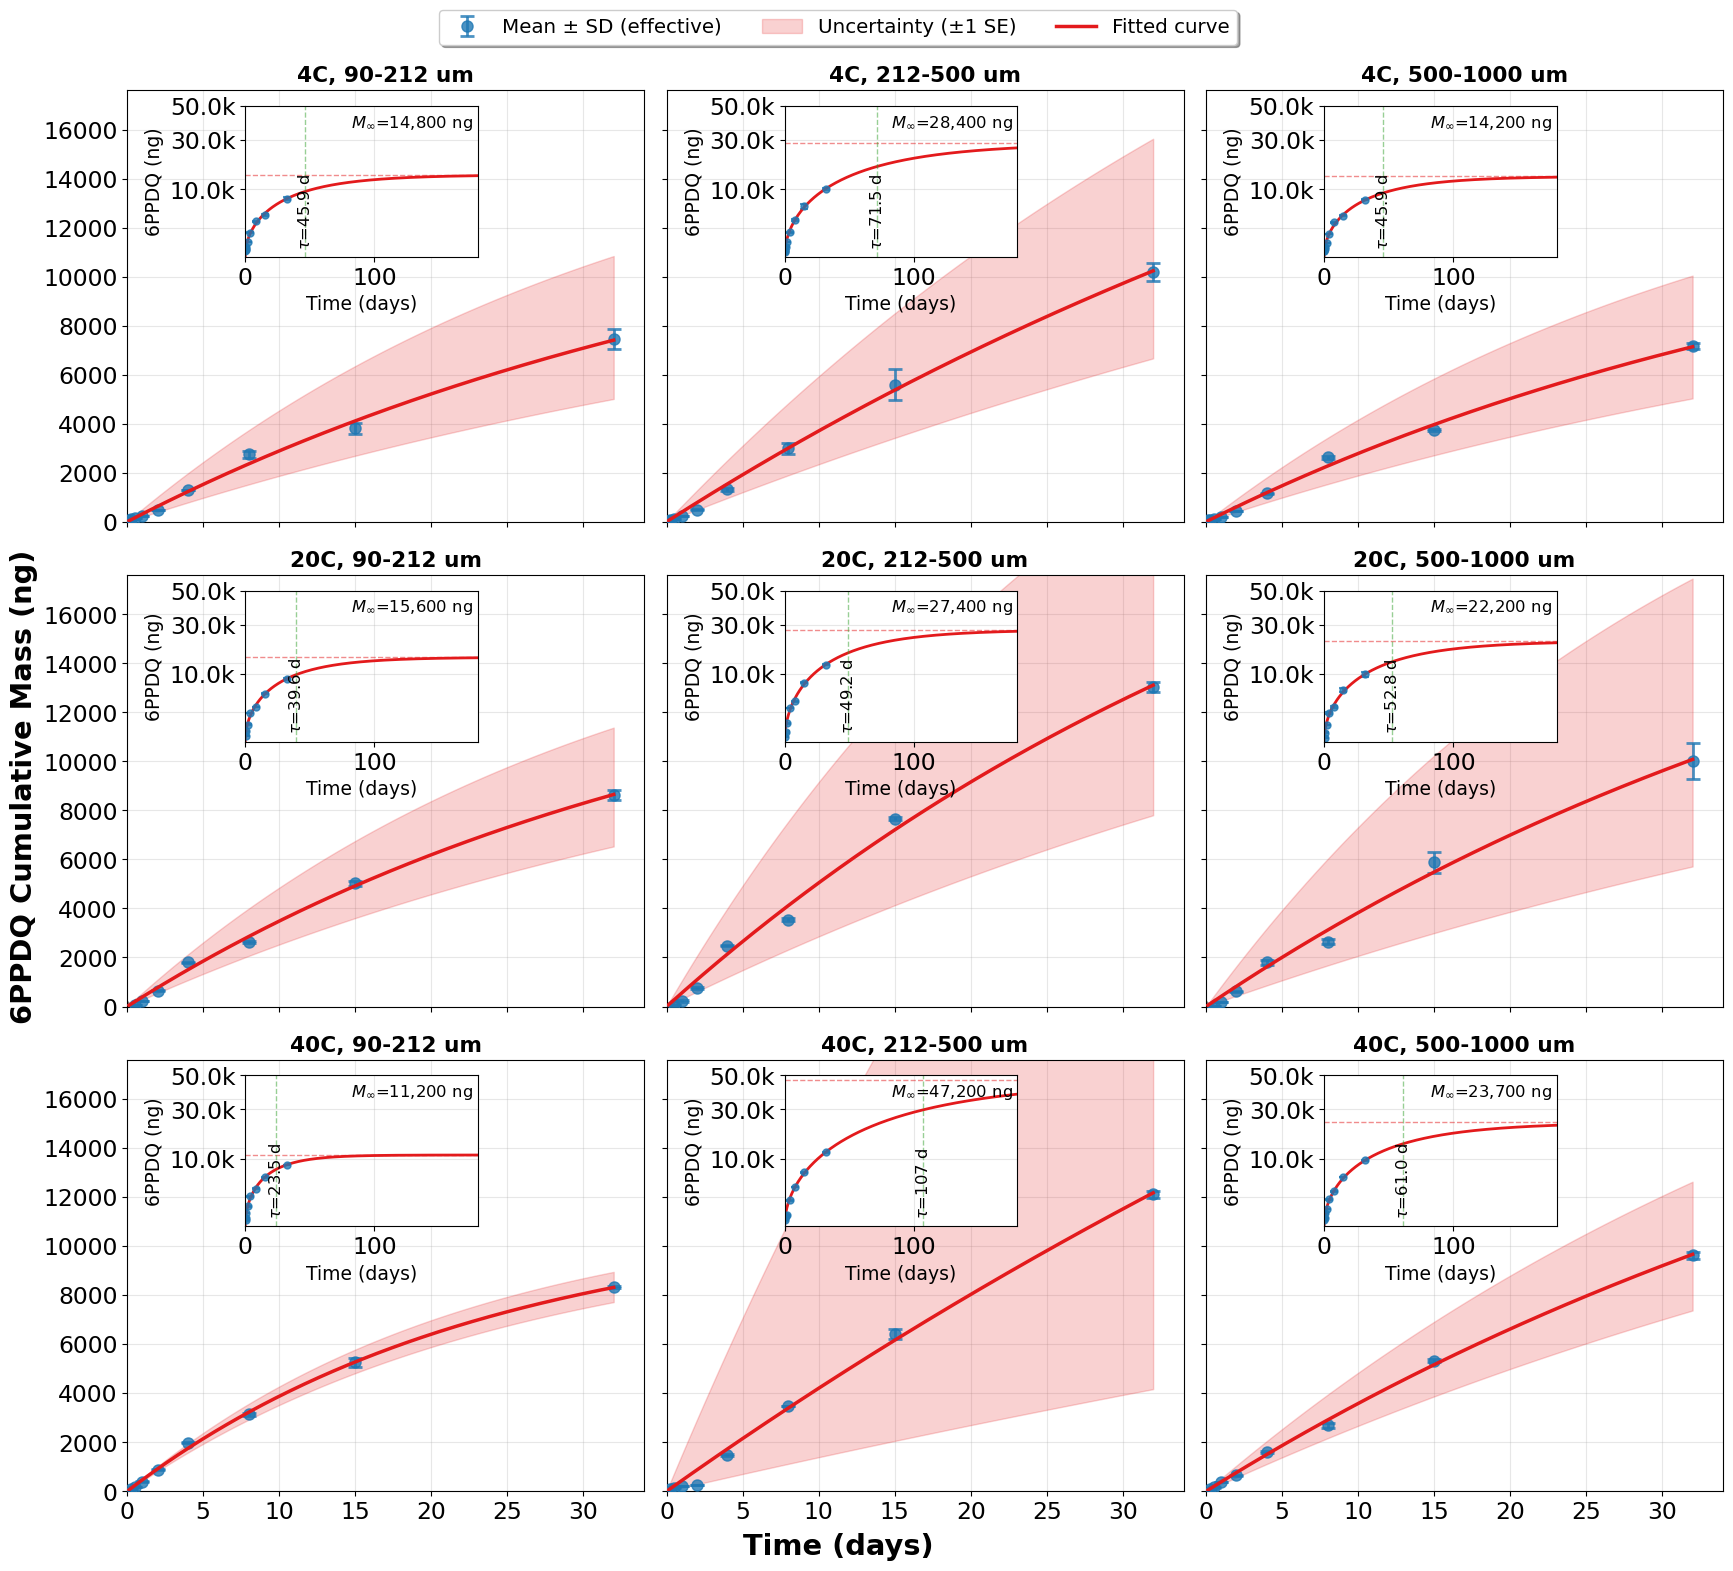

In [5]:

# Create comprehensive 3x3 plot showing all conditions
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

# Set fixed y-axis limit for all panels
y_max = 17600
inset_y_max = 50000  # Extended to accommodate M_inf ~47179 in panel 8 (40C, M)

# Track legend handles for the figure legend
legend_handles = []
legend_labels = []
legend_added = False

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FixedLocator, FuncFormatter

for i, temp in enumerate(temperatures):
    for j, size in enumerate(sizes):
        ax = axes[i, j]
        condition = (temp, size)
        
        if results[condition] is None:
            ax.text(0.5, 0.5, 'Fitting Failed', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=18.2)
            ax.set_title(f'{temp}, {size_labels[size]}', fontsize=15.6, fontweight='bold')
            continue
        
        res = results[condition]
        
        # Plot mean of all data points with error bars (effective points only)
        h2 = ax.errorbar(res['time_eff'], res['ppdq_mean_eff'], 
                   yerr=res['ppdq_std_eff'],
                   fmt='o', color=(31/255, 120/255, 180/255), markersize=8, linewidth=2,
                   capsize=5, capthick=2, alpha=0.8,
                   label='Mean ± SD (effective)', zorder=3)
        if not legend_added:
            legend_handles.append(h2)
            legend_labels.append('Mean ± SD (effective)')
        
        # Plot non-effective data points in gray (not used for fitting)
        non_eff_idx = [idx for idx in range(len(res['time'])) 
                      if idx not in res['effective_idx']]
        if len(non_eff_idx) > 0:
            h3 = ax.plot(res['time'][non_eff_idx], res['ppdq_mean'][non_eff_idx], 
                   'x', color='gray', markersize=10, markeredgewidth=2,
                   label='Non-effective', zorder=2)
            if not legend_added:
                legend_handles.append(h3[0])
                legend_labels.append('Non-effective')
        
        # Generate smooth curve for plotting
        time_smooth = np.linspace(res['time'].min(), res['time'].max(), 200)
        fit_curve = first_order_model(time_smooth, res['M_inf'], res['tau'])
        
        # Calculate uncertainty bounds using parameter errors
        # Upper bound: M_inf + err, tau - err (faster approach to higher asymptote)
        # Lower bound: M_inf - err, tau + err (slower approach to lower asymptote)
        M_inf_upper = res['M_inf'] + res['M_inf_err']
        M_inf_lower = max(0, res['M_inf'] - res['M_inf_err'])  # Keep non-negative
        tau_upper = res['tau'] + res['tau_err']
        tau_lower = max(0.01, res['tau'] - res['tau_err'])  # Keep positive
        
        # Generate envelope curves
        # Upper envelope: high M_inf, low tau (reaches high value quickly)
        curve_upper = first_order_model(time_smooth, M_inf_upper, tau_lower)
        # Lower envelope: low M_inf, high tau (reaches low value slowly)
        curve_lower = first_order_model(time_smooth, M_inf_lower, tau_upper)
        
        # Plot uncertainty band
        h4 = ax.fill_between(time_smooth, curve_lower, curve_upper, 
                       color=(227/255, 26/255, 28/255), alpha=0.2, zorder=2,
                       label='Uncertainty (±1 SE)')
        if not legend_added:
            legend_handles.append(h4)
            legend_labels.append('Uncertainty (±1 SE)')
        
        # Plot fitted curve
        h5 = ax.plot(time_smooth, fit_curve, '-', color=(227/255, 26/255, 28/255), linewidth=2.5, zorder=4)
        if not legend_added:
            legend_handles.append(h5[0])
            legend_labels.append('Fitted curve')
            legend_added = True
        
        # Formatting
        ax.set_title(f'{temp}, {size_labels[size]}', fontsize=15.6, fontweight='bold')
        ax.grid(True, which='both', ls='-', alpha=0.3)
        ax.tick_params(labelsize=13)  # Base font size for all ticks
        
        # Only show y-axis labels for first column with larger font
        if j == 0:
            ax.set_ylabel('')  # Remove individual ylabel
            ax.tick_params(axis='y', labelsize=16.9)  # 30% larger: 13 * 1.3
        else:
            ax.set_yticklabels([])
        
        # Only show x-axis labels for bottom row with larger font
        if i == 2:
            ax.set_xlabel('')  # Remove individual xlabel
            ax.tick_params(axis='x', labelsize=16.9)  # 30% larger: 13 * 1.3
        else:
            ax.set_xticklabels([])
        
        # Set unified axis limits for all panels
        ax.set_xlim(0, 34)
        ax.set_ylim(0, y_max)
        
        # Add inset plot showing extrapolation to 180 days for all panels
        ax_inset = inset_axes(ax, width="45%", height="35%", loc='upper left',
                             bbox_to_anchor=(0.215, -0.02, 1, 1), bbox_transform=ax.transAxes)
        
        # Plot experimental data points
        ax_inset.errorbar(res['time_eff'], res['ppdq_mean_eff'], 
                        yerr=res['ppdq_std_eff'],
                        fmt='o', color=(31/255, 120/255, 180/255), markersize=5, linewidth=1.5,
                        capsize=3, capthick=1.5, alpha=0.8)
        
        # Plot fitted curve extrapolated to 180 days
        time_extrap = np.linspace(0, 180, 500)
        fit_extrap = first_order_model(time_extrap, res['M_inf'], res['tau'])
        ax_inset.plot(time_extrap, fit_extrap, '-', color=(227/255, 26/255, 28/255), linewidth=2)
        
        # Apply sqrt nonlinear scale to inset y-axis only:
        #   - stretches the lower range (0-10k) giving data more visual room
        #   - compresses the upper range so M_inf~47179 fits without crowding small values
        ax_inset.set_yscale('function', functions=(
            lambda x: np.sqrt(np.maximum(x, 0)),
            lambda x: np.where(x >= 0, x ** 2, 0)
        ))
        
        # Format inset - increase font size by 30%
        ax_inset.set_xlabel('Time (days)', fontsize=13.52)  # 10.4 * 1.3
        ax_inset.set_ylabel('6PPDQ (ng)', fontsize=13.52)    # 10.4 * 1.3
        ax_inset.tick_params(labelsize=16.9)  # 13 * 1.3
        ax_inset.grid(True, alpha=0.3)
        ax_inset.set_xlim(0, 180)
        ax_inset.set_ylim(0, inset_y_max)
        # Show only 10k, 30k, 50k tick marks
        ax_inset.yaxis.set_major_locator(FixedLocator([10000, 30000, 50000]))
        ax_inset.yaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f'{x / 1000:.1f}k'))
        
        # Add horizontal line showing M_inf (asymptotic value)
        ax_inset.axhline(y=res['M_inf'], color=(227/255, 26/255, 28/255), linestyle='--', 
                       linewidth=1, alpha=0.5)
        ax_inset.text(0.98, 0.95, f"$M_\\infty$={format_sigfig(res['M_inf'], use_comma=True)} ng", 
                    transform=ax_inset.transAxes, fontsize=11.83,  # 9.1 * 1.3
                    ha='right', va='top')
        
        # Add vertical line showing tau (characteristic time)
        ax_inset.axvline(x=res['tau'], color=(51/255, 160/255, 44/255), linestyle='--', 
                       linewidth=1, alpha=0.5)
        # Place tau label in upper half, black color
        ax_inset.text(res['tau'], 0.05, f"$\\tau$={format_sigfig(res['tau'])} d", 
                    transform=ax_inset.get_xaxis_transform(), fontsize=11.83,  # 9.1 * 1.3
                    ha='center', va='bottom', color='black', rotation=90)

# Add common axis labels with larger font
fig.text(0.5, 0.02, 'Time (days)', ha='center', fontsize=20.8, fontweight='bold')
fig.text(0.04, 0.5, '6PPDQ Cumulative Mass (ng)', va='center', rotation='vertical', 
         fontsize=20.8, fontweight='bold')

# Add figure legend
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.992),
          ncol=5, fontsize=14.3, frameon=True, fancybox=True, shadow=True)

plt.tight_layout(rect=[0.05, 0.03, 1, 0.96])  # Adjust layout to make room for labels and legend
fig.savefig('Figure_3.png', dpi=300, bbox_inches='tight')
plt.show()


In [6]:
# Create summary table of fitted parameters
print('=' * 150)
print('SUMMARY TABLE: First-Order Leaching Model Parameters')
print('=' * 150)
print(f"{'Temperature':<12} {'Size':<15} {'M_inf (ng)':<30} {'M_inf (ug/g)':<25} {'tau (days)':<25} {'t_90% (days)':<30}")
print('-' * 150)

# Tire rubber mass used in experiment
tire_mass_g = 0.5  # grams

for temp in temperatures:
    for size in sizes:
        condition = (temp, size)
        if results[condition] is not None:
            res = results[condition]
            M_inf_ng_str = format_value_with_error(res['M_inf'], res['M_inf_err'], use_comma=True)
            M_inf_ug_per_g = res['M_inf'] / 1000 / tire_mass_g
            M_inf_err_ug_per_g = res['M_inf_err'] / 1000 / tire_mass_g
            M_inf_str = format_value_with_error(M_inf_ug_per_g, M_inf_err_ug_per_g)
            tau_str = format_value_with_error(res['tau'], res['tau_err'])
            
            # t_90% = tau * ln(10), with uncertainty propagated from tau.
            t90 = res['tau'] * np.log(10)
            t90_err = res['tau_err'] * np.log(10)
            t90_str = format_value_with_error(t90, t90_err)
            
            print(f'{temp:<12} {size_labels[size]:<15} {M_inf_ng_str:<30} {M_inf_str:<25} {tau_str:<25} {t90_str:<30}')
        else:
            print(f"{temp:<12} {size_labels[size]:<15} {'Failed':<30} {'Failed':<25} {'Failed':<25} {'Failed':<30}")

print('=' * 150)
print('')
print('Note: Uncertainties are standard errors from the covariance matrix')
print(f'Note: M_inf (ug/g) values are normalized by tire rubber mass ({tire_mass_g} g)')
print('Note: t_90% is the time at which 90% of M_inf is leached (calculated as tau * ln(10))')
print('Note: Uncertainty in t_90% is propagated from tau uncertainty: sigma(t90) = ln(10) * sigma(tau)')


SUMMARY TABLE: First-Order Leaching Model Parameters
Temperature  Size            M_inf (ng)                     M_inf (ug/g)              tau (days)                t_90% (days)                  
------------------------------------------------------------------------------------------------------------------------------------------------------
4C           90-212 um       14,800 +/- 2,940               29.5 +/- 5.87             45.9 +/- 12.1             106 +/- 28.0                  
4C           212-500 um      28,400 +/- 6,090               56.7 +/- 12.2             71.5 +/- 18.5             165 +/- 42.6                  
4C           500-1000 um     14,200 +/- 2,540               28.4 +/- 5.08             45.9 +/- 10.9             106 +/- 25.1                  
20C          90-212 um       15,600 +/- 2,270               31.2 +/- 4.54             39.6 +/- 7.97             91.1 +/- 18.4                 
20C          212-500 um      27,400 +/- 7,130               54.9 +/- 14.3        